Saving loan-data-new-train.csv to loan-data-new-train (1).csv
(614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban         

/tmp/ipykernel_3438/1086613588.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_3438/1086613588.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

Logistic Regression Accuracy: 78.86%
Random Forest Accuracy: 75.61%
Logistic Regression Confusion Matrix:
[[18 25]
 [ 1 79]]

Random Forest Confusion Matrix:
[[18 25]
 [ 5 75]]
Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

Random Forest Report:
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123

              Feature  Importance
9      Credit_History    0.262914
5     ApplicantIncome    0.202666
7          LoanAm

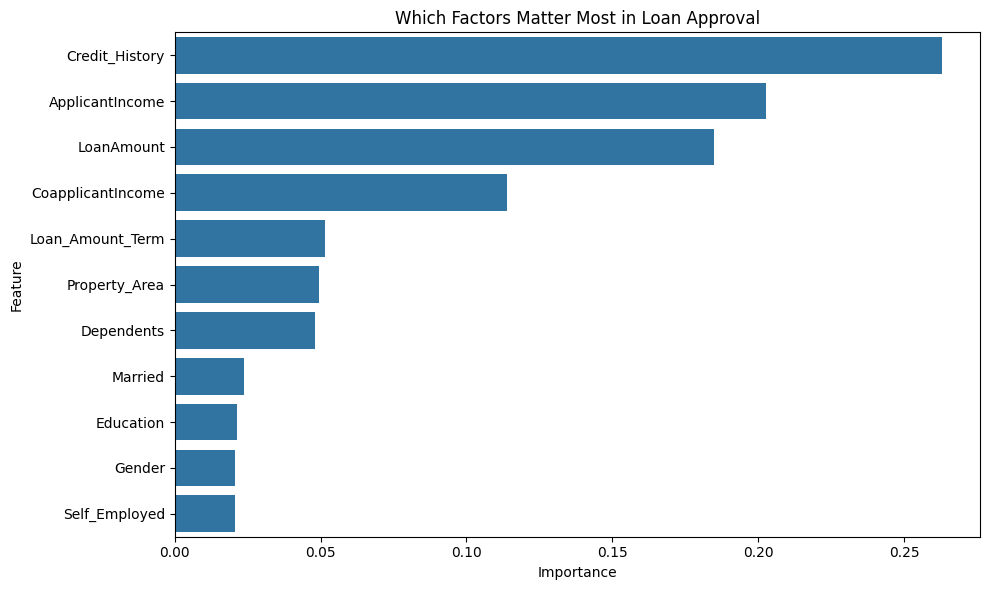

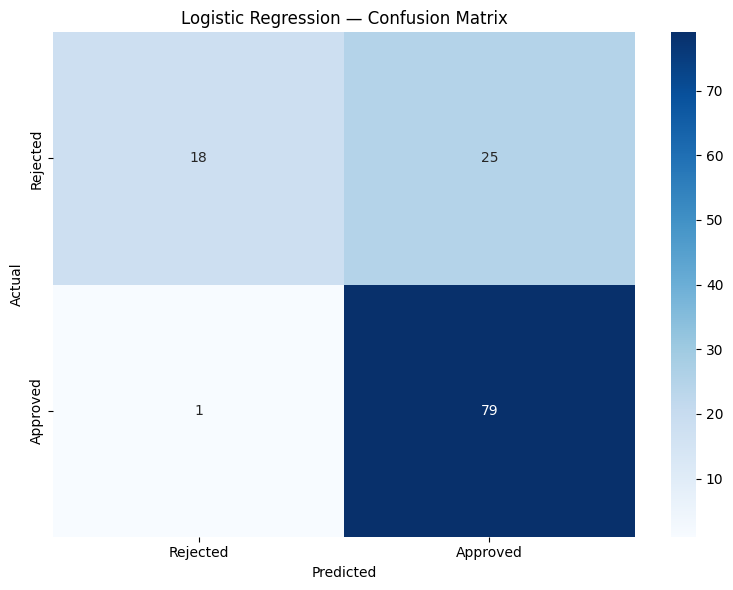

In [26]:
# Step 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


#uploading the dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('loan-data-new-train.csv')

# Step 3: First look at the data
print(df.shape)        # total no.of cols and rows
print(df.head())       # first 5 rows
print(df.info())       # this gives the null values and data type
print(df.describe())   # this is gives the stats of the data

# how many missing values each column has
print(df.isnull().sum())

# Filling missing values in categorical columns using mode (most frequent value)
# I used mode here because these are mostly category-type columns,
# and replacing with the most common value is a simple and reasonable approach.

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# Gender has some missing values, so I replaced them with the most frequent gender in the dataset
# Same idea here — filling missing marital status with the most common value
# Dependents is also categorical (like 0, 1, 2, 3+), so using mode makes sense
# Replacing missing self-employed values with the most common category
# Credit history is very important for loan prediction,
# so instead of dropping rows, I filled missing values with the most frequent value

# Loan term is filled with mode as well since most people tend to have similar loan durations

# Numerical columns — fill with MEDIAN (not mean, because income data is skewed)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Verify — should show all zeros now
print(df.isnull().sum())

# Loan_ID is just an identifier, tells the model nothing so dropping it
df.drop('Loan_ID', axis=1, inplace=True)

# LabelEncoder converts each unique text value to a number
le = LabelEncoder()

# List of all columns that are text/categorical
categorical_cols = ['Gender', 'Married', 'Dependents',
                    'Education', 'Self_Employed',
                    'Property_Area', 'Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)

print(df.columns.tolist())

# X = everything the model learns FROM (input variables)
X = df.drop('Loan_Status', axis=1)

# y = what the model is trying to PREDICT (output)
y = df['Loan_Status']

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

# Build and train the model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

# Check accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%")

# Build and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

# Check accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

# Logistic Regression confusion matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

# Random Forest confusion matrix
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("Logistic Regression Report:")
print(classification_report(y_test, lr_pred))

print("Random Forest Report:")
print(classification_report(y_test, rf_pred))

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot it
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Which Factors Matter Most in Loan Approval')
plt.tight_layout()
plt.show()


# Clean visual confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()